In [ ]:
# Plot saved 1D L²-minimization results for ReLU^k random features.
#
# Loads .npz files produced by the variational least-squares and mass-matrix
# (collocation / assembled) L² experiments, then plots mean L² error vs number
# of neurons (log-log) for a target of the form Π_i sin(m π x).
#
# Compared methods (from the loaded result files):
#   1) Variational least squares  — L2VariationalLeastSquare-1d-relu{k}.npz
#   2) Mass matrix assembly       — L2minimization-1d-relu{k}.npz
#

import matplotlib.pyplot as plt 
import numpy as np 
import torch 
import os 
import sys 
import time 
import random 


[  6  10  18  34  66 130 256 508]
[2.12677046e-03 2.84702249e-04 3.68560890e-05 4.57867550e-06
 1.33815518e-06 4.28169642e-06 4.09551103e-06 7.02490264e-06]
[  6  10  18  34  66 130 256 508]
[2.12677046e-03 2.84702249e-04 3.68561038e-05 7.57907089e-06
 4.87987014e-05 1.04382281e-05 6.97794212e-06 9.23115340e-05]


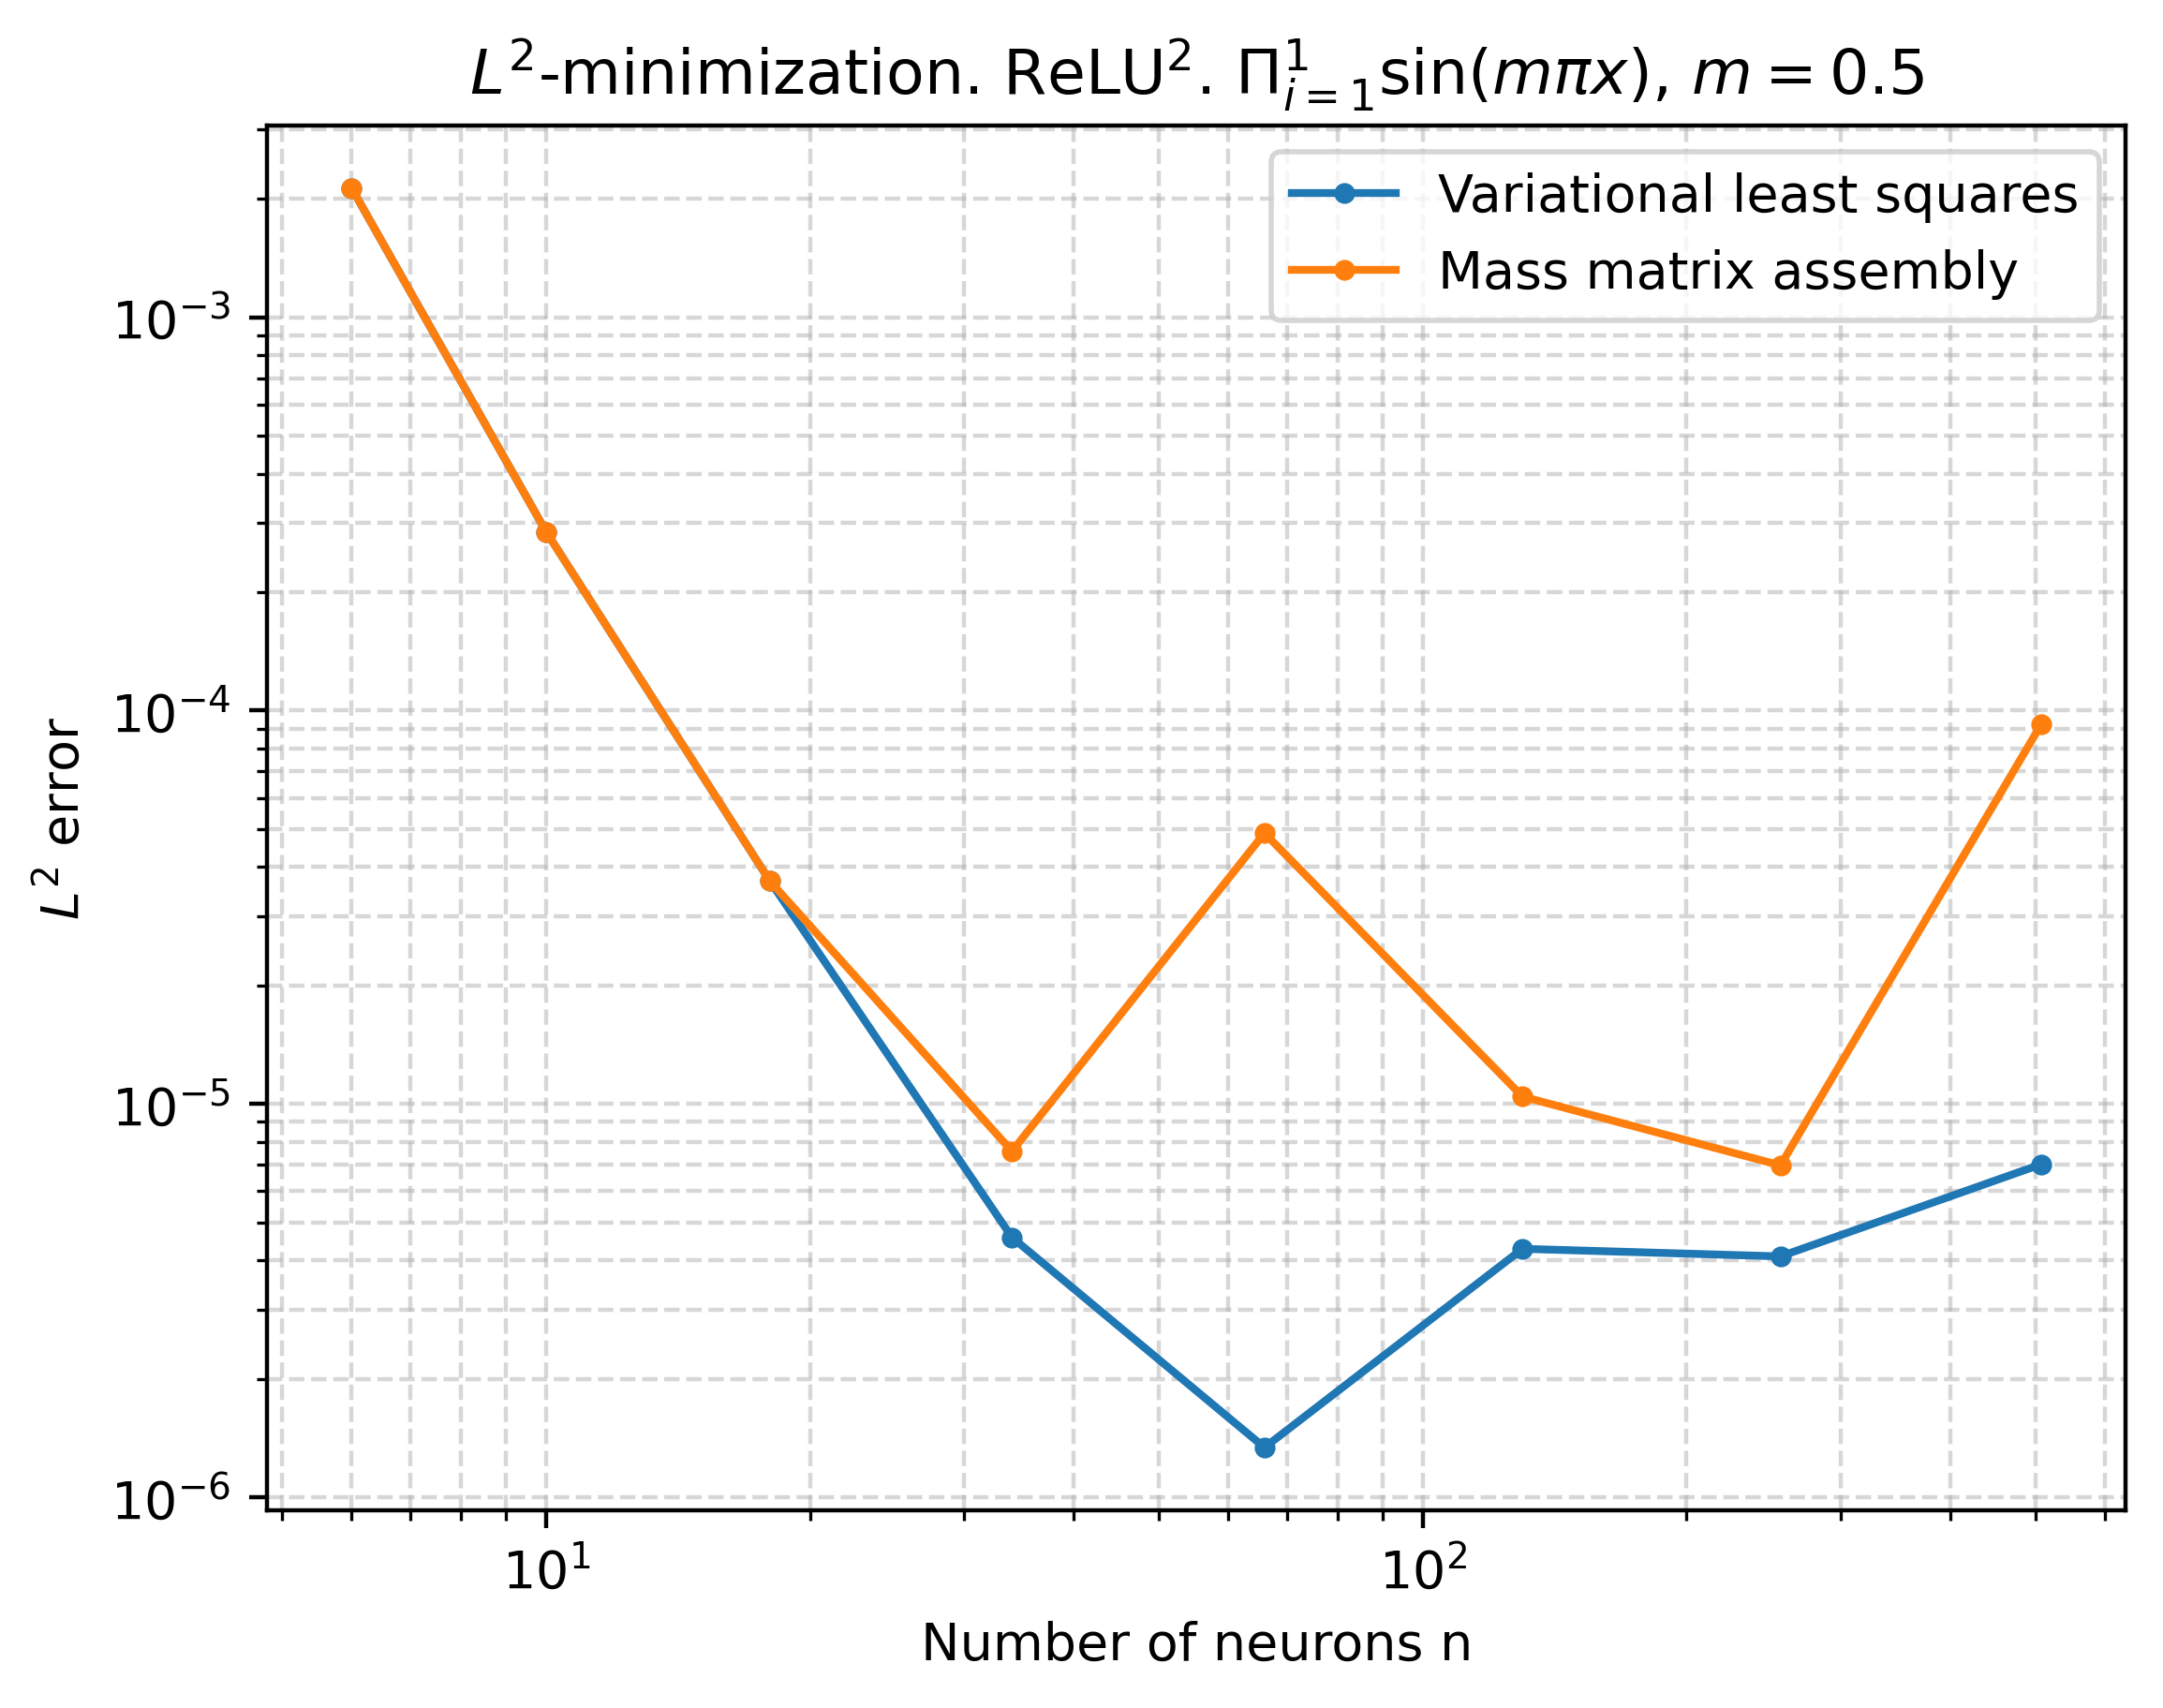

In [5]:
#read the data
relu_k = 2  
d= 1 
m = 0.5
data = np.load('L2VariationalLeastSquare-1d-relu2.npz')
actual_neuron_arr_m1   = data['actual_neuron_arr']
mean_err_l2_arr_2_m1 = data['mean_err_l2_arr_2']
print(actual_neuron_arr_m1)
print(mean_err_l2_arr_2_m1)

data = np.load("L2minimization-1d-relu2.npz")
actual_neuron_arr_m2   = data['actual_neuron_arr']
mean_err_l2_arr_2_m2 = data['mean_err_l2_arr_2']
print(actual_neuron_arr_m2)
print(mean_err_l2_arr_2_m2)

plt.figure(dpi =400)
legend1 = r"Variational least squares"
legend2 = r"Mass matrix assembly"
title = f"$L^2$-minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$" 
plt.plot(actual_neuron_arr_m1, mean_err_l2_arr_2_m1, '.-', label = legend1)
plt.plot(actual_neuron_arr_m2, mean_err_l2_arr_2_m2, '.-', label = legend2)
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel("$L^2$ error")
plt.xlabel("Number of neurons n")
plt.title(title) 
plt.grid(True, which="both", ls="--", alpha=0.5)
